In [1]:
using FluorescenceCorrelationFitting

In [2]:
using DelimitedFiles

filepath = raw"C:\Users\aiyan\Downloads\BodTz10_10nM_NoBCN_OD1_0_FCS.txt"
data = read_fcs(filepath; start_idx = 40, end_idx = 210);

[ Info: Precompiling FluorescenceCorrelationFittingDelimitedFilesExt [04f9bed4-162b-5684-bfef-ffd3146fc5bd] (cache misses: wrong dep version loaded (2), mismatched flags (4))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


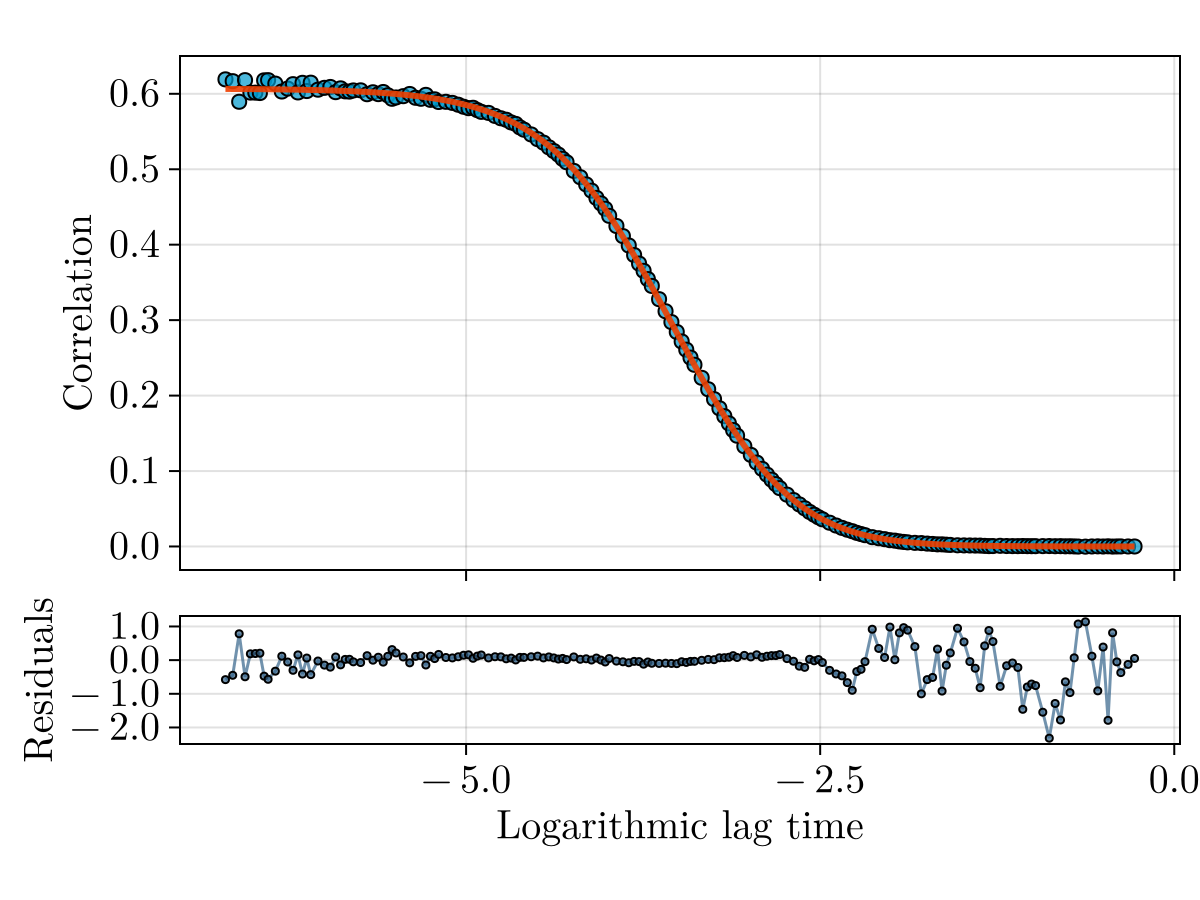

In [ ]:
using CairoMakie
using LaTeXStrings

diffusivity=5e-11; offset=0.0
spec = FCSModelSpec(dim = FluorescenceCorrelationFitting.d3, anom = FluorescenceCorrelationFitting.none, n_diff=2, offset = 0.0)

initial_parameters = [0.6, 6, 5e-4, 1e-4, 0.5]
lower_bounds = [0.5, 1, 1e-4, 1e-5, 0.0]
upper_bounds = [0.7, 20, 2e-3, 5e-3, 1.0]
fit = fcs_fit(spec, data.channels[3], initial_parameters; lower = lower_bounds, upper = upper_bounds)
fig, _ = fcs_plot(fit, data.channels[3])
fig

In [8]:
using PrettyTables

fcs_table(fit; units=["", "", "μ", "μ", ""], gof_metric=aic)

Parameters 
 Values 
 Std. Dev. 
 
 
 
 
 Current amplitude 
 0.6069 
 0.003312 
 
 
 Structure factor 
 2.242 
 0.4285 
 
 
 Residence time [μs] 
 407.1 
 72.23 
 
 
 Dynamic lifetime 1 [μs] 
 134.2 
 54.89 
 
 
 Dynamic population fraction 1 
 0.1354 
 0.07887 
 
 
 
 
 aic = 1575.21

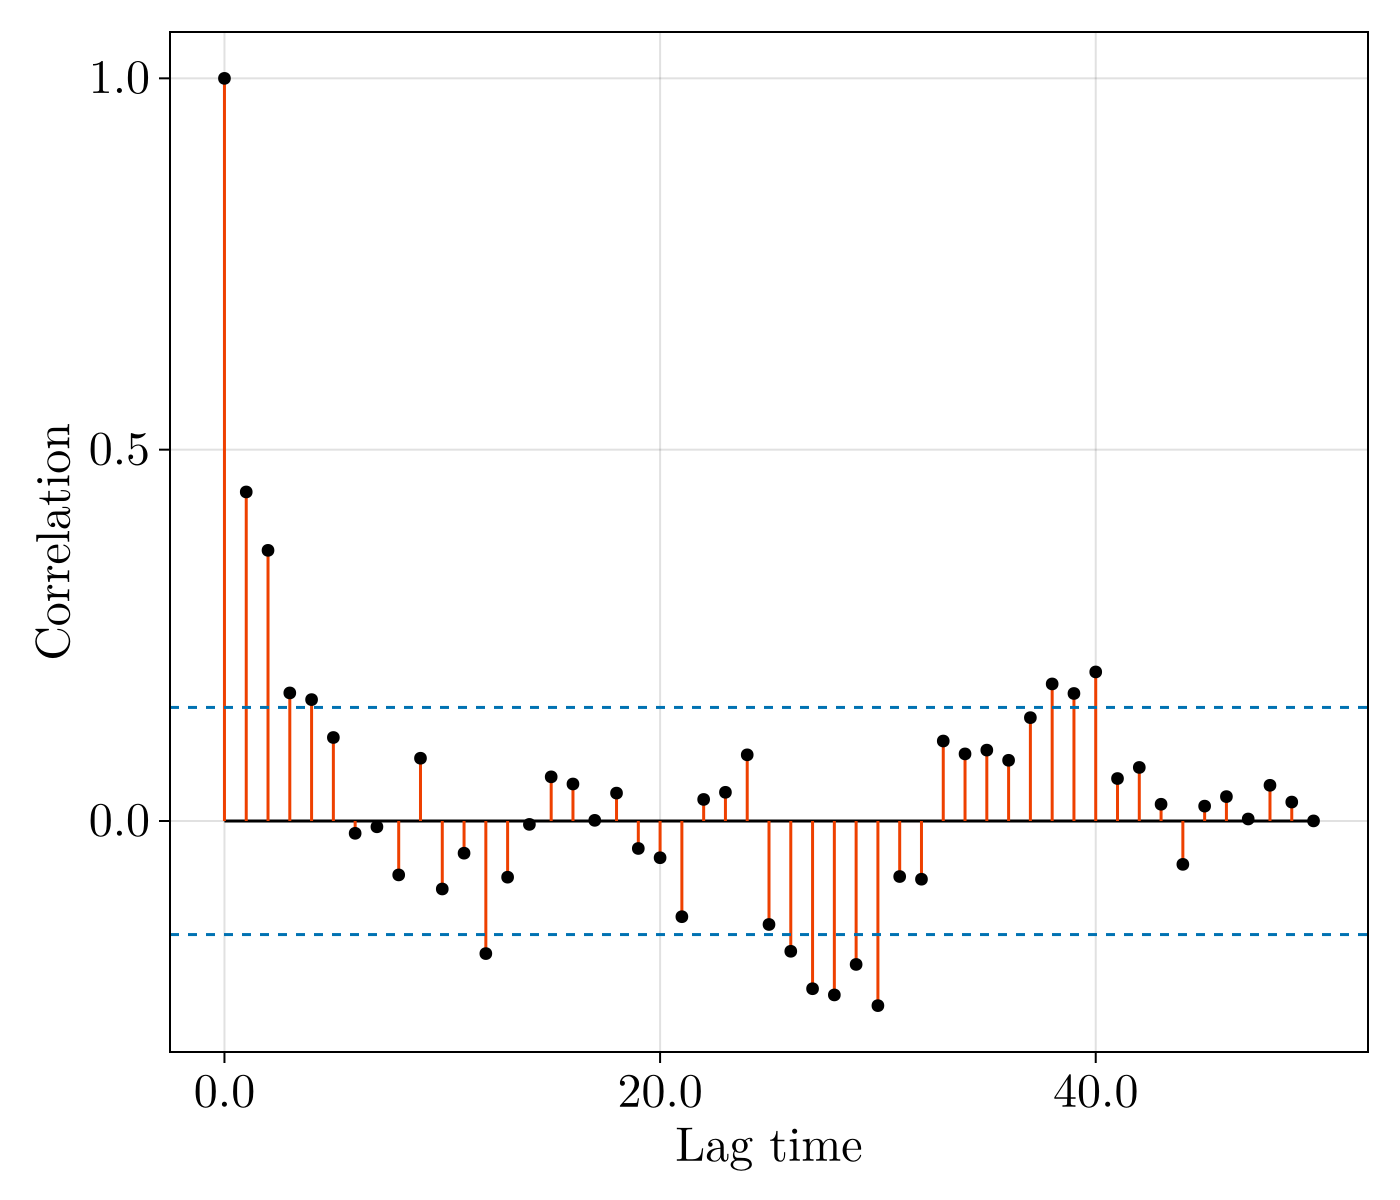

In [5]:
fig = resid_acf_plot(fit; 
    acf_kwargs=(maxlag=50,), 
    plot_kwargs=(
        figure_kw=(size=(700,600),fontsize=24), 
        stem_kw=(stemcolor=:orangered2, color=:black, trunkcolor=:black), 
        hline_kw=(linestyle=:dash,)
    )
)
fig